# Modeling comparison for fraud detection

Notebook này so sánh 4 thuật toán:
- Logistic Regression
- Decision Tree
- Bayesian (GaussianNB + SVD)
- ANN (MLP + SVD)

Dữ liệu đọc từ `artifacts/processed_csv/` do `fraud_detection_btl.ipynb` xuất (ví dụ **20 cột** feature sau bước chọn `selected_features_model`).

- `X_train.csv` / `y_train.csv`: train **gốc** (imbalanced).
- `X_train_balanced.csv` / `y_train_balanced.csv`: train sau **2.8 SMOTE**.

Biến `USE_BALANCED_TRAIN`:
- `False`: chỉ huấn luyện trên tập **imbalanced**.
- `True`: huấn luyện **song song** trên **imbalanced** và **balanced** (cùng 4 thuật toán), bảng kết quả có cột `train_variant` để so sánh.

Metrics: `precision`, `recall`, `f1`, `roc_auc`, `pr_auc`, `accuracy` + confusion matrix + classification report.

Sau confusion matrix: **Visualization** (ANN: learning curve, threshold tuning, calibration, ROC/PR, confusion) → PNG trong `artifacts/modeling_results/figures/`.

Sau cell cuối: lưu thêm **mô hình đã fit** (`.pkl`, dùng `joblib`) trong `artifacts/modeling_results/trained_models/`.

In [2]:
from pathlib import Path
import time
import joblib
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import TruncatedSVD

# from sklearn.linear_model import LogisticRegression
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
)
from sklearn.calibration import calibration_curve

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
TARGET = "is_fraud"


In [6]:
# Load dữ liệu đã export từ notebook tiền xử lý
# True: huấn luyện song song imbalanced + balanced (SMOTE); False: chỉ imbalanced
USE_BALANCED_TRAIN = False

ARTIFACT_DIR = Path("../artifacts") if Path.cwd().name == "notebooks" else Path("artifacts")
processed_dir = ARTIFACT_DIR / "processed_csv"

required_files = [
    "X_train.csv", "y_train.csv",
    "X_valid.csv", "X_test.csv", "y_valid.csv", "y_test.csv",
]
if USE_BALANCED_TRAIN:
    required_files += ["X_train_balanced.csv", "y_train_balanced.csv"]

missing = [f for f in required_files if not (processed_dir / f).exists()]
if missing:
    raise FileNotFoundError(
        f"Thiếu file trong {processed_dir.resolve()}: {missing}. "
        "Chạy cell export cuối fraud_detection_btl.ipynb; nếu USE_BALANCED_TRAIN=True cần đã chạy 2.8.2 trước export."
    )

X_train = pd.read_csv(processed_dir / "X_train.csv")
y_train = pd.read_csv(processed_dir / "y_train.csv")[TARGET]

X_train_balanced = y_train_balanced = None
if USE_BALANCED_TRAIN:
    X_train_balanced = pd.read_csv(processed_dir / "X_train_balanced.csv")
    y_train_balanced = pd.read_csv(processed_dir / "y_train_balanced.csv")[TARGET]
    assert list(X_train.columns) == list(X_train_balanced.columns), "Schema train imbalanced vs balanced không khớp"

X_valid = pd.read_csv(processed_dir / "X_valid.csv")
X_test = pd.read_csv(processed_dir / "X_test.csv")
y_valid = pd.read_csv(processed_dir / "y_valid.csv")[TARGET]
y_test = pd.read_csv(processed_dir / "y_test.csv")[TARGET]

print("Loaded from:", processed_dir.resolve())
print("Train imbalanced:", X_train.shape, "fraud rate", y_train.mean())
if USE_BALANCED_TRAIN:
    print("Train balanced:  ", X_train_balanced.shape, "fraud rate", y_train_balanced.mean())
print("Valid:", X_valid.shape, "| Test:", X_test.shape)
print("Fraud rate valid/test:", y_valid.mean(), y_test.mean())


Loaded from: D:\Project\DataMining-DataWarehouse\Source\artifacts\processed_csv
Train imbalanced: (1037340, 20) fraud rate 0.005753176393467908
Valid: (259335, 20) | Test: (555719, 20)
Fraud rate valid/test: 0.005930553145545337 0.0038598644278853163


In [7]:
# Cột khớp với CSV từ fraud_detection_btl: object/category -> one-hot, còn lại -> numeric + scale
feature_columns = list(X_train.columns)
if TARGET in feature_columns:
    raise ValueError(f"X_train không được chứa cột target '{TARGET}'")

categorical_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_features = [c for c in feature_columns if c not in categorical_features]

print(f"Số cột feature: {len(feature_columns)} (numeric={len(numeric_features)}, categorical={len(categorical_features)})")
print("Categorical:", categorical_features)

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

transformers = [("num", numeric_pipeline, numeric_features)]
if categorical_features:
    transformers.append(("cat", categorical_pipeline, categorical_features))

base_preprocessor = ColumnTransformer(transformers=transformers, remainder="drop")

# TruncatedSVD bắt buộc n_components <= số cột sau prep (ví dụ 20 feature số → không dùng được 60)
_probe_prep = clone(base_preprocessor)
_n_rows = min(20000, len(X_train))
_n_prep = _probe_prep.fit_transform(X_train.iloc[:_n_rows]).shape[1]
SVD_NB_COMPONENTS = max(1, min(60, _n_prep))
SVD_MLP_COMPONENTS = max(1, min(80, _n_prep))
print(f"Chiều sau preprocessor: {_n_prep} → TruncatedSVD: NB={SVD_NB_COMPONENTS}, MLP={SVD_MLP_COMPONENTS}")


Số cột feature: 20 (numeric=20, categorical=0)
Categorical: []
Chiều sau preprocessor: 20 → TruncatedSVD: NB=20, MLP=20


In [15]:
models = {
    # "LogisticRegression": Pipeline([
    #     ("prep", base_preprocessor),
    #     ("clf", LogisticRegression(
    #         class_weight="balanced",
    #         max_iter=300,
    #         random_state=RANDOM_STATE,
    #         n_jobs=-1,
    #     )),
    # ]),
    # "DecisionTree": Pipeline([
    #     ("prep", base_preprocessor),
    #     ("clf", DecisionTreeClassifier(
    #         max_depth=12,
    #         min_samples_leaf=20,
    #         class_weight="balanced",
    #         random_state=RANDOM_STATE,
    #     )),
    # ]),
    # "Bayesian_GaussianNB": Pipeline([
    #     ("prep", base_preprocessor),
    #     ("svd", TruncatedSVD(n_components=SVD_NB_COMPONENTS, random_state=RANDOM_STATE)),
    #     ("clf", GaussianNB()),
    # ]),
    "ANN_MLP": Pipeline([
        ("prep", base_preprocessor),
        ("svd", TruncatedSVD(n_components=SVD_MLP_COMPONENTS, random_state=RANDOM_STATE)),
        ("clf", MLPClassifier(
            # Hyperparameters
            hidden_layer_sizes=(64, 32),
            activation="relu",
            # learning_rate="adaptive",      # hoặc 'constant'
            # learning_rate_init=0.001,      # thử 0.01
            early_stopping=True,
            validation_fraction=0.1,
            max_iter=200,
            random_state=RANDOM_STATE,
        )),
    ]),
}

train_jobs = [("imbalanced", X_train, y_train)]
if USE_BALANCED_TRAIN:
    train_jobs.append(("balanced_smote", X_train_balanced, y_train_balanced))

artifacts = {}

for train_variant, Xt, yt in train_jobs:
    for name, model_template in models.items():
        print(f"\n=== [{train_variant}] Training {name} ===")
        model = clone(model_template)

        t0 = time.perf_counter()
        model.fit(Xt, yt)
        train_seconds = time.perf_counter() - t0

        mlp = model.named_steps.get("clf")
        loss_curve = getattr(mlp, "loss_curve_", None)
        if loss_curve is not None:
            loss_curve = list(loss_curve)
        val_scores = getattr(mlp, "validation_scores_", None)
        if val_scores is not None:
            val_scores = list(val_scores)

        valid_prob = model.predict_proba(X_valid)[:, 1]
        test_prob = model.predict_proba(X_test)[:, 1]

        artifacts.setdefault(train_variant, {})[name] = {
            "fitted_model": model,
            "valid_prob": valid_prob,
            "test_prob": test_prob,
            "train_seconds": train_seconds,
            "loss_curve": loss_curve,
            "validation_scores": val_scores,
            "n_iter": getattr(mlp, "n_iter_", None),
        }

        print(f"  => train_seconds={train_seconds:.2f}s, n_iter_={getattr(mlp, 'n_iter_', None)}")

print("Đã train (single fit) và cache predict_proba vào artifacts.")


=== [imbalanced] Training ANN_MLP ===
  => train_seconds=91.27s, n_iter_=15
Đã train (single fit) và cache predict_proba vào artifacts.


In [ ]:
# Từ Threshold tuning -> 0.194 là tối ưu
threshold = 0.194

def evaluate_binary(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob),
    }

def evaluate_all(artifacts, y_valid, y_test, threshold):
    results = []
    for train_variant, models_dict in artifacts.items():
        for name, data in models_dict.items():
            valid_metrics = evaluate_binary(y_valid, data["valid_prob"], threshold)
            test_metrics = evaluate_binary(y_test, data["test_prob"], threshold)

            row = {
                "train_variant": train_variant,
                "model": name,
            }
            row.update({f"valid_{k}": v for k, v in valid_metrics.items()})
            row.update({f"test_{k}": v for k, v in test_metrics.items()})
            results.append(row)

    return pd.DataFrame(results)

results_df = evaluate_all(artifacts, y_valid, y_test, threshold)

sort_cols = ["valid_pr_auc", "valid_f1"]
if USE_BALANCED_TRAIN:
    sort_cols = ["train_variant"] + sort_cols
    asc = [True, False, False]
else:
    asc = [False, False]

results_df = results_df.sort_values(sort_cols, ascending=asc)
results_df

,train_variant,model,valid_accuracy,valid_precision,valid_recall,valid_f1,valid_roc_auc,valid_pr_auc,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,test_pr_auc
0,imbalanced,ANN_MLP,0.997737,0.809772,0.808192,0.808981,0.992471,0.865215,0.998172,0.755314,0.778555,0.766758,0.991649,0.832713


In [22]:
# Bảng so sánh chính (validation + test); train_variant = imbalanced | balanced_smote
cols = [
    "train_variant", "model",
    "valid_precision", "valid_recall", "valid_f1", "valid_roc_auc", "valid_pr_auc",
    "test_precision", "test_recall", "test_f1", "test_roc_auc", "test_pr_auc",
]
display(results_df[cols].reset_index(drop=True))

if USE_BALANCED_TRAIN:
    for v in results_df["train_variant"].unique():
        sub = results_df[results_df["train_variant"] == v].sort_values(
            ["valid_pr_auc", "valid_f1"], ascending=False
        )
        best = sub.iloc[0]["model"]
        print(f"\nTốt nhất theo valid PR-AUC (train={v}): {best}")
else:
    sub = results_df.sort_values(["valid_pr_auc", "valid_f1"], ascending=False)
    print(f"\nMô hình tốt nhất theo valid PR-AUC: {sub.iloc[0]['model']}")


,train_variant,model,valid_precision,valid_recall,valid_f1,valid_roc_auc,valid_pr_auc,test_precision,test_recall,test_f1,test_roc_auc,test_pr_auc
0,imbalanced,ANN_MLP,0.809772,0.808192,0.808981,0.992471,0.865215,0.755314,0.778555,0.766758,0.991649,0.832713



Mô hình tốt nhất theo valid PR-AUC: ANN_MLP


In [23]:
# Confusion matrix + classification report (validation) theo từng train_variant + model
for train_variant in sorted(artifacts.keys()):
    for name in artifacts[train_variant]:
        valid_prob = artifacts[train_variant][name]["valid_prob"]
        y_pred = (valid_prob >= threshold).astype(int)

        cm = confusion_matrix(y_valid, y_pred)
        print(f"\n[{train_variant}] {name} - Validation confusion matrix")
        print(cm)
        print(f"\n[{train_variant}] {name} - Validation classification report")
        print(classification_report(y_valid, y_pred, digits=4, zero_division=0))



[imbalanced] ANN_MLP - Validation confusion matrix
[[257505    292]
 [   295   1243]]

[imbalanced] ANN_MLP - Validation classification report
              precision    recall  f1-score   support

           0     0.9989    0.9989    0.9989    257797
           1     0.8098    0.8082    0.8090      1538

    accuracy                         0.9977    259335
   macro avg     0.9043    0.9035    0.9039    259335
weighted avg     0.9977    0.9977    0.9977    259335



## Visualization (ANN / MLP)

Không còn biểu đồ so sánh nhiều thuật toán. Chỉ vẽ cho **ANN_MLP** (mỗi `train_variant` một đường / subplot nếu có nhiều variant):

- **Learning curve**: `loss_curve_` + `validation_scores_` (khi `early_stopping=True`).
- **Threshold tuning**: precision / recall / F1 trên validation theo ngưỡng (sweep).
- **Calibration**: reliability diagram trên validation (`calibration_curve`).
- **ROC / PR (validation)** và **Confusion matrix (validation)** cho ANN_MLP để đánh giá mô hình theo chuẩn fraud detection.

Ảnh PNG: `artifacts/modeling_results/figures/` với đuôi `threshold_<giá trị>` khi liên quan ngưỡng. Chạy sau cell training + cell đặt `threshold`.

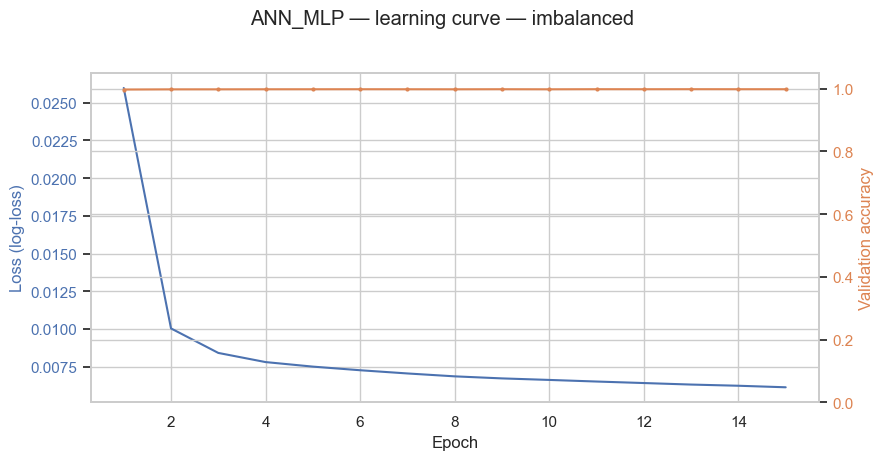

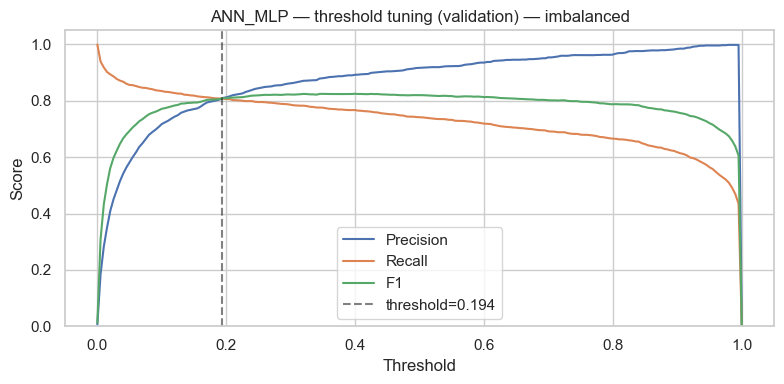

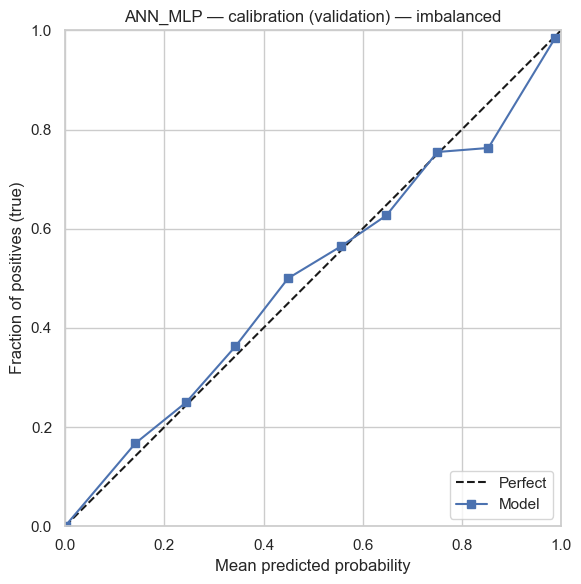

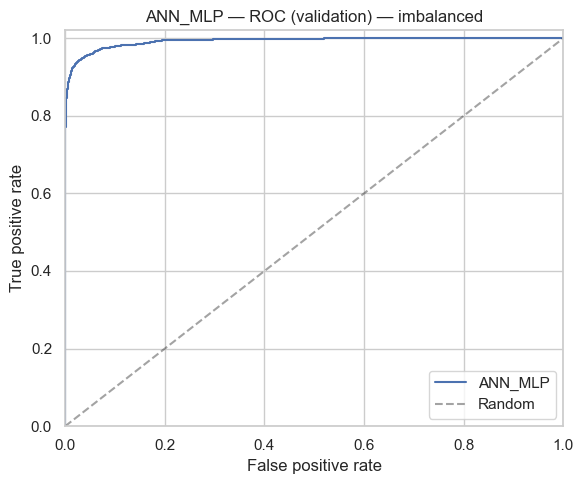

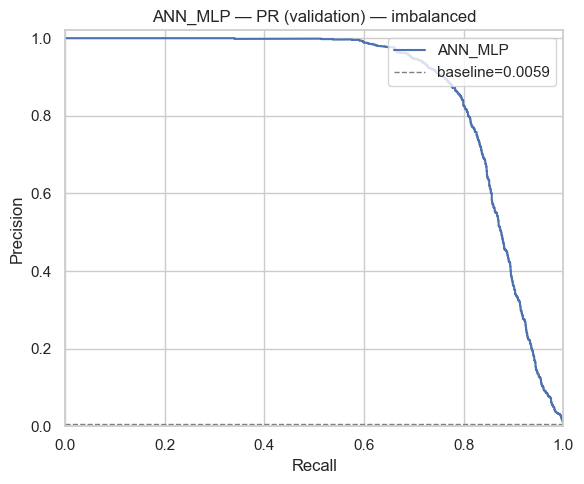

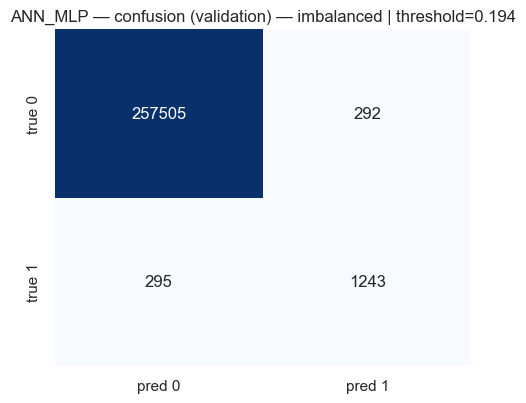

Đã lưu figure tại: D:\Project\DataMining-DataWarehouse\Source\artifacts\modeling_results\figures


In [24]:
# --- Visualization: ANN_MLP only (sau train + cell threshold) ---
ANN_NAME = "ANN_MLP"

fig_dir = ARTIFACT_DIR / "modeling_results" / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)
_thr_suffix = f"threshold_{float(threshold):g}"

def _ann_epochs(loss_curve):
    if loss_curve is None:
        return None
    return np.arange(1, len(loss_curve) + 1)

# 1) Learning curve: loss + validation accuracy (theo epoch)
for tv in sorted(artifacts.keys()):
    if ANN_NAME not in artifacts[tv]:
        continue
    payload = artifacts[tv][ANN_NAME]
    loss_curve = payload.get("loss_curve")
    val_scores = payload.get("validation_scores")
    epochs = _ann_epochs(loss_curve)
    if epochs is None or loss_curve is None:
        print(f"[{tv}] Không có loss theo epoch. Bỏ qua learning curve.")
        continue
    fig, ax1 = plt.subplots(figsize=(9, 4.5))
    ax1.plot(epochs, loss_curve, color="C0", label="Train loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss (log-loss)", color="C0")
    ax1.tick_params(axis="y", labelcolor="C0")
    has_val_acc = val_scores is not None and len(val_scores)
    if has_val_acc:
        ep_val = np.arange(1, len(val_scores) + 1)
        ax2 = ax1.twinx()
        ax2.plot(ep_val, val_scores, color="C1", label="Val accuracy", marker=".", ms=4)
        ax2.set_ylabel("Validation accuracy", color="C1")
        ax2.tick_params(axis="y", labelcolor="C1")
        ax2.set_ylim(0, 1.05)
    fig.suptitle(f"ANN_MLP — learning curve — {tv}", y=1.02)
    plt.tight_layout()
    safe_tv = str(tv).replace(" ", "_")
    fig.savefig(fig_dir / f"ann_learning_curve_{safe_tv}_{_thr_suffix}.png", dpi=150, bbox_inches="tight")
    plt.show()

    if not has_val_acc:
        print(f"[{tv}] Không có validation_scores_ (bật early_stopping).")

# 2) Threshold tuning (validation)
thr_grid = np.linspace(0, 1, 201)
for tv in sorted(artifacts.keys()):
    if ANN_NAME not in artifacts[tv]:
        continue
    vp = artifacts[tv][ANN_NAME]["valid_prob"]
    precisions, recalls, f1s = [], [], []
    for t in thr_grid:
        yp = (vp >= t).astype(int)
        precisions.append(precision_score(y_valid, yp, zero_division=0))
        recalls.append(recall_score(y_valid, yp, zero_division=0))
        f1s.append(f1_score(y_valid, yp, zero_division=0))
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(thr_grid, precisions, label="Precision")
    ax.plot(thr_grid, recalls, label="Recall")
    ax.plot(thr_grid, f1s, label="F1")
    ax.axvline(float(threshold), color="k", linestyle="--", alpha=0.55, label=f"threshold={threshold}")
    ax.set_xlabel("Threshold")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.05)
    ax.legend(loc="best")
    ax.set_title(f"ANN_MLP — threshold tuning (validation) — {tv}")
    plt.tight_layout()
    safe_tv = str(tv).replace(" ", "_")
    fig.savefig(fig_dir / f"ann_threshold_tuning_{safe_tv}_{_thr_suffix}.png", dpi=150, bbox_inches="tight")
    plt.show()

# 3) Calibration (validation)
for tv in sorted(artifacts.keys()):
    if ANN_NAME not in artifacts[tv]:
        continue
    vp = artifacts[tv][ANN_NAME]["valid_prob"]
    prob_true, prob_pred = calibration_curve(y_valid, vp, n_bins=10, strategy="uniform")
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.plot([0, 1], [0, 1], "k--", label="Perfect")
    ax.plot(prob_pred, prob_true, "s-", label="Model")
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Fraction of positives (true)")
    ax.set_title(f"ANN_MLP — calibration (validation) — {tv}")
    ax.legend(loc="lower right")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect("equal", adjustable="box")
    plt.tight_layout()
    safe_tv = str(tv).replace(" ", "_")
    fig.savefig(fig_dir / f"ann_calibration_valid_{safe_tv}_{_thr_suffix}.png", dpi=150, bbox_inches="tight")
    plt.show()

# 4) ROC curve (validation)
for tv in sorted(artifacts.keys()):
    if ANN_NAME not in artifacts[tv]:
        continue
    vp = artifacts[tv][ANN_NAME]["valid_prob"]
    fpr, tpr, _ = roc_curve(y_valid, vp)
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(fpr, tpr, label="ANN_MLP")
    ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Random")
    ax.set_xlabel("False positive rate")
    ax.set_ylabel("True positive rate")
    ax.set_title(f"ANN_MLP — ROC (validation) — {tv}")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.02)
    ax.legend(loc="lower right")
    plt.tight_layout()
    safe_tv = str(tv).replace(" ", "_")
    fig.savefig(fig_dir / f"ann_roc_valid_{safe_tv}_{_thr_suffix}.png", dpi=150, bbox_inches="tight")
    plt.show()

# 5) PR curve (validation)
for tv in sorted(artifacts.keys()):
    if ANN_NAME not in artifacts[tv]:
        continue
    vp = artifacts[tv][ANN_NAME]["valid_prob"]
    prec, rec, _ = precision_recall_curve(y_valid, vp)
    baseline = float(y_valid.mean())
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(rec, prec, label="ANN_MLP")
    ax.axhline(baseline, color="gray", linestyle="--", linewidth=1, label=f"baseline={baseline:.4f}")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title(f"ANN_MLP — PR (validation) — {tv}")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.02)
    ax.legend(loc="upper right")
    plt.tight_layout()
    safe_tv = str(tv).replace(" ", "_")
    fig.savefig(fig_dir / f"ann_pr_valid_{safe_tv}_{_thr_suffix}.png", dpi=150, bbox_inches="tight")
    plt.show()

# 6) Confusion matrix (validation, theo threshold hiện tại)
for tv in sorted(artifacts.keys()):
    if ANN_NAME not in artifacts[tv]:
        continue
    vp = artifacts[tv][ANN_NAME]["valid_prob"]
    yp = (vp >= float(threshold)).astype(int)
    cm = confusion_matrix(y_valid, yp)
    fig, ax = plt.subplots(figsize=(4.8, 4.2))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["pred 0", "pred 1"],
        yticklabels=["true 0", "true 1"],
        ax=ax,
    )
    ax.set_title(f"ANN_MLP — confusion (validation) — {tv} | threshold={threshold}")
    plt.tight_layout()
    safe_tv = str(tv).replace(" ", "_")
    fig.savefig(fig_dir / f"ann_confusion_valid_{safe_tv}_{_thr_suffix}.png", dpi=150, bbox_inches="tight")
    plt.show()

print("Đã lưu figure tại:", fig_dir.resolve())

In [25]:
# Lưu kết quả so sánh ra CSV + mô hình đã fit (.pkl)
out_dir = ARTIFACT_DIR / "modeling_results"
out_dir.mkdir(parents=True, exist_ok=True)
_thr_suffix = f"threshold_{float(threshold):g}"
comparison_path = out_dir / f"model_comparison_{_thr_suffix}.csv"
results_df.to_csv(comparison_path, index=False)
print("Saved:", comparison_path.resolve())

models_dir = out_dir / "trained_models"
models_dir.mkdir(parents=True, exist_ok=True)
for train_variant, by_name in artifacts.items():
    for name, payload in by_name.items():
        safe = f"{train_variant}__{name}".replace(" ", "_")
        path = models_dir / f"{safe}.pkl"
        joblib.dump(payload["fitted_model"], path)
        print("Model:", path.resolve())
print(f"Đã lưu {sum(len(v) for v in artifacts.values())} file .pkl tại: {models_dir.resolve()}")


Saved: D:\Project\DataMining-DataWarehouse\Source\artifacts\modeling_results\model_comparison_threshold_0.194.csv
Model: D:\Project\DataMining-DataWarehouse\Source\artifacts\modeling_results\trained_models\imbalanced__ANN_MLP.pkl
Đã lưu 1 file .pkl tại: D:\Project\DataMining-DataWarehouse\Source\artifacts\modeling_results\trained_models
